***SmartCart E-Commerce Customer Segmentation System***

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('smartcart_customers.csv')

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [4]:
print(df.isnull().sum())

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64


***data preprocessing***

In [5]:
#Handle Missing Values
df['Income']=df['Income'].fillna(df['Income'].median())

In [6]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


***Feature Engineering***

In [7]:
#age 
df['Age']=2026-df['Year_Birth']

In [8]:
#Customer Joining Date
df['Dt_Customer']=pd.to_datetime(df['Dt_Customer'],dayfirst=True)
reference_date=df['Dt_Customer'].max()
df['Cutsomer_Tenure_Days']=(reference_date -df['Dt_Customer']).dt.days

In [9]:
#Total Spending
df['Total_Spendings']=df['MntWines']+df['MntFruits']+df['MntMeatProducts']+df['MntFishProducts']+df['MntSweetProducts']+df['MntGoldProds']
#children
df['Total_Children']=df['Kidhome']+df['Teenhome']

In [10]:
df['Education'].value_counts()
#Undergraduate, Graduate ,Postgraduate
df['Education']=df['Education'].replace(
    {
        'Basic':'Undergraduate',
        '2n Cycle':'Undergraduate',
        'Master':'Postgraduate',
        'PhD':'Postgraduate',
        'Graduation':'Graduate'
    }
)

In [11]:
#Marital Status
df['Marital_Status'].value_counts()
#Undergraduate, Graduate ,Postgraduate
df['Living_With']=df['Marital_Status'].replace(
    {
        'Married':'partner',
        'Together':'partner',
        'Single':'Alone',
        'Divorced':'Alone',
        'Absurd':'Alone',
        'YOLO':'Alone','Widow':'Alone'
    }
)

In [12]:
df['Living_With'].value_counts()

Living_With
partner    1444
Alone       796
Name: count, dtype: int64

In [13]:
#Drop Columns
cols_to_Drop=[
    'ID','Year_Birth','Marital_Status','Kidhome',
       'Teenhome','Dt_Customer','MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds'
]
df_cleaned=df.drop(columns = cols_to_Drop)

In [14]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Cutsomer_Tenure_Days,Total_Spendings,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,partner


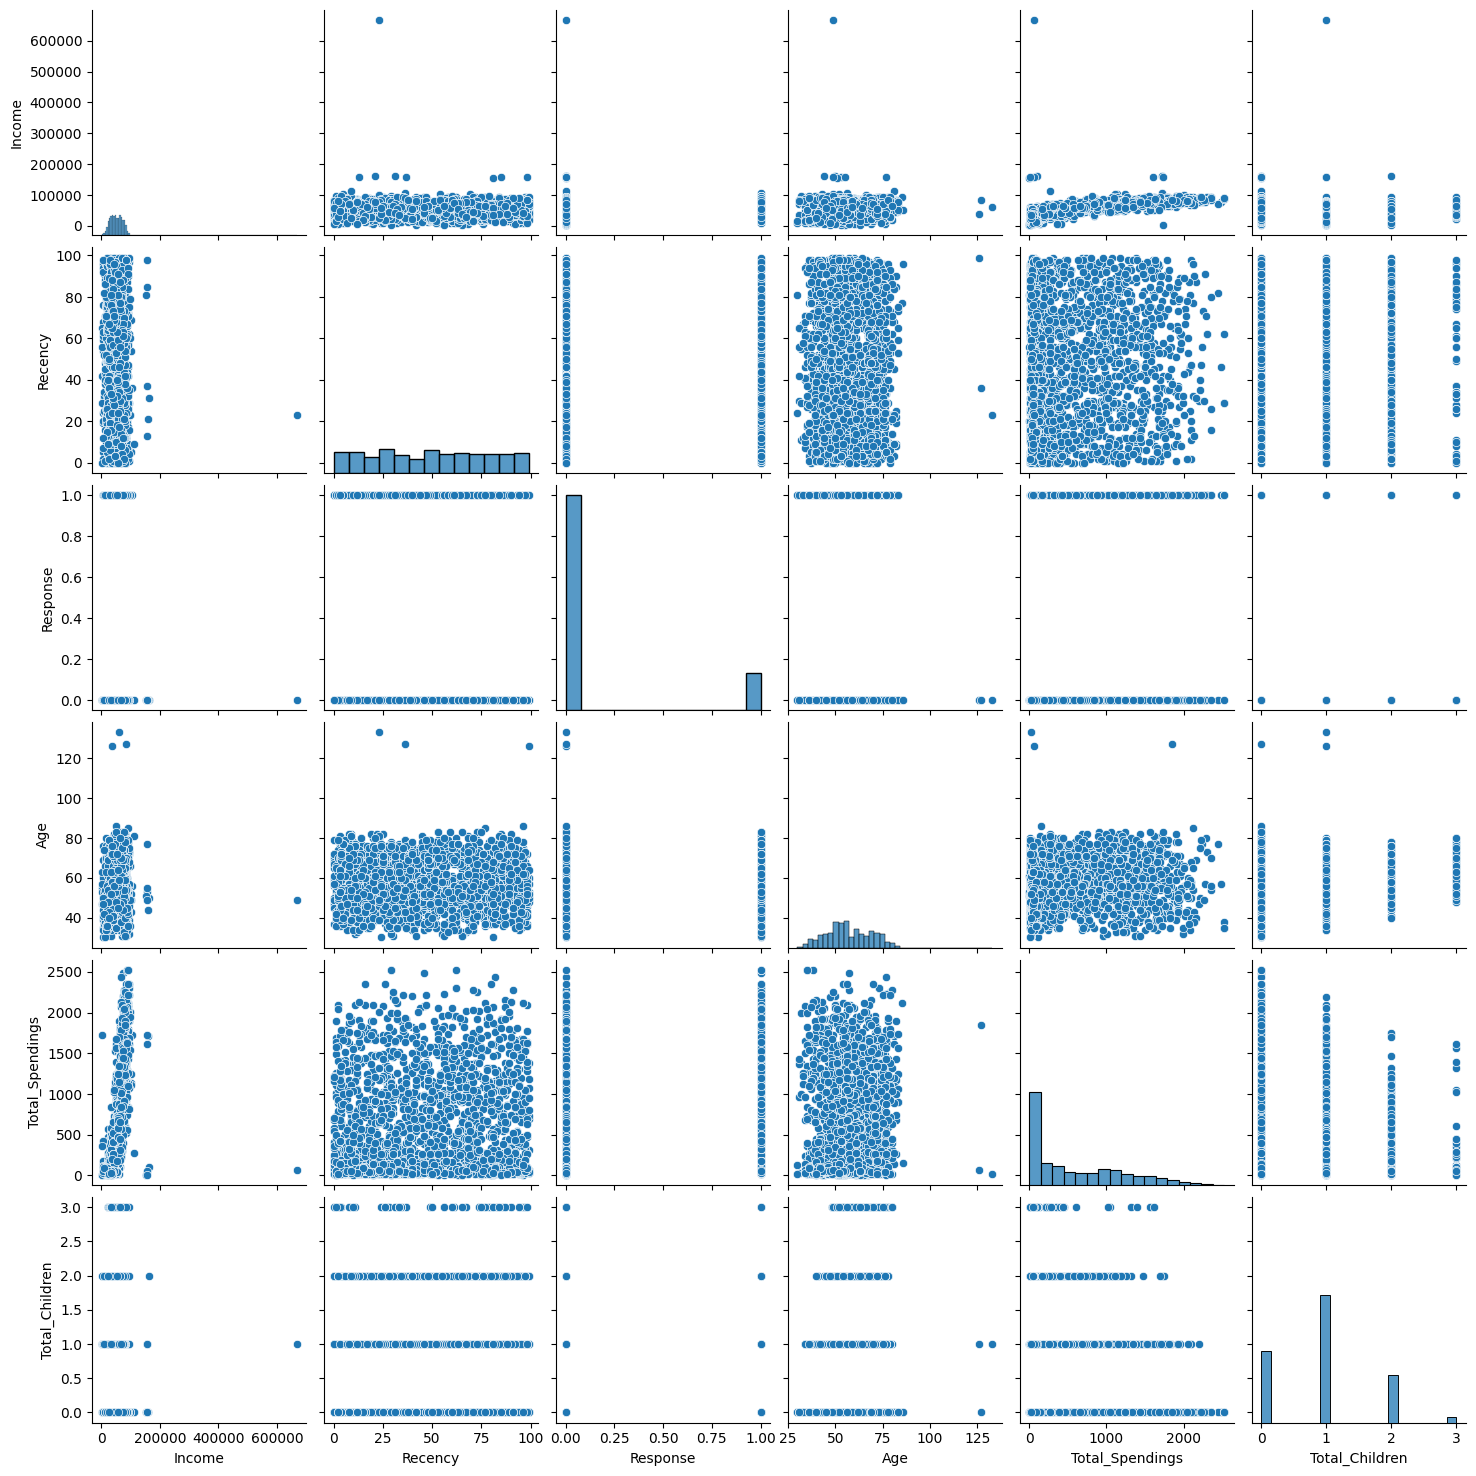

In [15]:
#outliers
cols=["Income","Recency","Response","Age","Total_Spendings","Total_Children"]
#relative plot of some feature-pair plots
sns.pairplot(df_cleaned[cols])

In [16]:
print("data size with outliers",len(df_cleaned))
df_cleaned=df_cleaned[(df_cleaned["Age"]<90)]
df_cleaned=df_cleaned[(df_cleaned["Income"]<600000)]
print("data size without outliers",len(df_cleaned))

data size with outliers 2240
data size without outliers 2236


***Heatmap***

In [17]:
corr=df_cleaned.corr(numeric_only=True)

<Axes: >

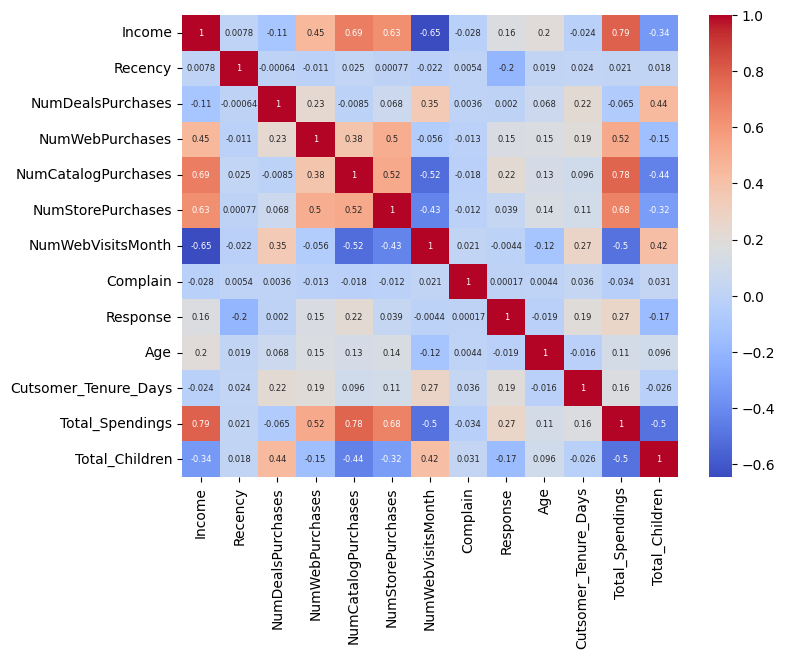

In [18]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size":6},
    cmap='coolwarm'
           )

In [19]:
df_cleaned.shape

(2236, 15)

In [20]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Cutsomer_Tenure_Days,Total_Spendings,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,partner


***Feature Scaling and One Hot Encoding***

In [21]:
from sklearn.preprocessing import OneHotEncoder

In [22]:
ohe=OneHotEncoder()
cat_cols=["Education","Living_With"]
enc_cols= ohe.fit_transform(df_cleaned[cat_cols])

In [23]:
enc_df= pd.DataFrame(enc_cols.toarray(),columns=ohe.get_feature_names_out(cat_cols),index=df_cleaned.index)

In [24]:
enc_df.head()

,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [25]:
df_encoded=pd.concat([df_cleaned.drop(columns=cat_cols),enc_df],axis=1)

In [26]:
print("shape:",df_encoded.shape)
df_encoded.head()

shape: (2236, 18)


,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Cutsomer_Tenure_Days,Total_Spendings,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


***Scaling And Standardization***

In [27]:
from sklearn.preprocessing import StandardScaler

In [28]:
x=df_encoded

In [29]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

In [30]:
x_scaled

array([[ 0.28894655,  0.30685572,  0.34873831, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [-0.262003  , -0.38397129, -0.16869955, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.91842301, -0.7984675 , -0.68613742, ..., -0.35877969,
        -0.74204052,  0.74204052],
       ...,
       [ 0.234898  ,  1.44672029, -0.68613742, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.80780332, -1.42021181, -0.16869955, ..., -0.35877969,
        -0.74204052,  0.74204052],
       [ 0.04280841, -0.31488859,  0.34873831, ..., -0.35877969,
        -0.74204052,  0.74204052]], shape=(2236, 18))

***Visualize***

In [31]:
x_scaled.shape

(2236, 18)

***Visualize***

In [32]:
from sklearn.decomposition import PCA

In [33]:
pca=PCA(n_components=3)
x_pca=pca.fit_transform(x_scaled)

In [34]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3d projection')

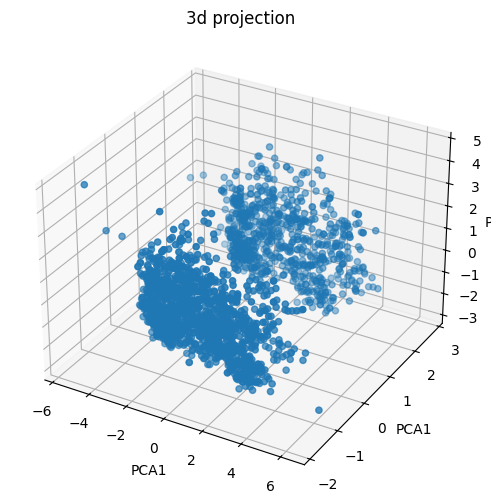

In [35]:
#plot
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2])
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA1")
ax.set_zlabel("PCA1")
ax.set_title("3d projection")

***Analyze K Value***

***1.Elbow Method***

In [36]:
from sklearn.cluster import KMeans
from kneed import KneeLocator
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit_predict(x_pca)
    wcss.append(kmeans.inertia_)

In [37]:
knee=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
optimal_k=knee.elbow

In [38]:
print("best_k:",optimal_k)

best_k: 4


Text(0, 0.5, 'wcss')

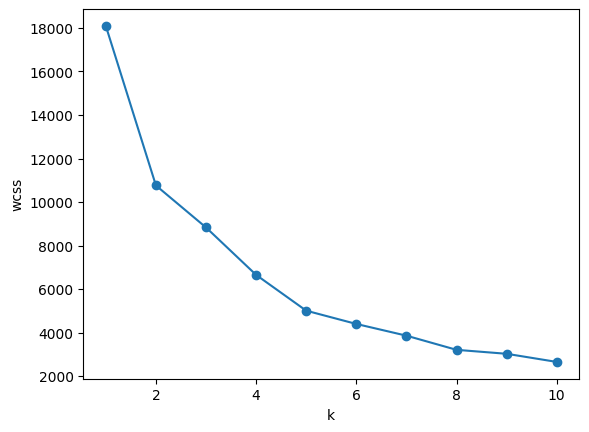

In [39]:
plt.plot(range(1,11),wcss,marker='o')
plt.xlabel("k")
plt.ylabel("wcss")

***2.Silhouette Score***

Text(0, 0.5, 'silhouette_score')

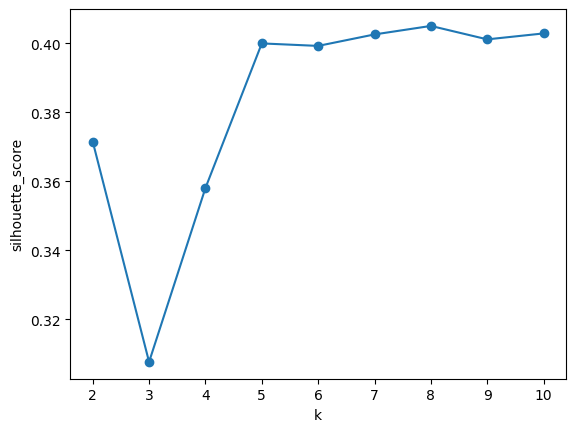

In [40]:
from sklearn.metrics import silhouette_score
scores=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    labels=kmeans.fit_predict(x_pca)
    score=silhouette_score(x_pca,labels)
    scores.append(score)

#plot
plt.plot(range(2,11),scores,marker='o')
plt.xlabel("k")
plt.ylabel("silhouette_score")

Text(0, 0.5, 'ss')

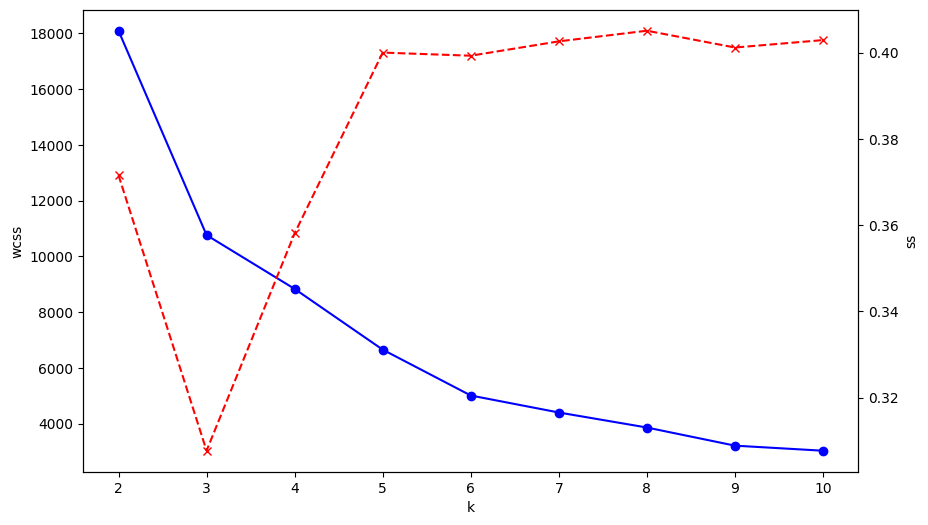

In [41]:
#combined_plot
k_range=range(2,11)
fig,ax1 =plt.subplots(figsize=(10,6))
ax1.plot(k_range,wcss[:len(k_range)],marker="o",color="blue")
ax1.set_xlabel("k")
ax1.set_ylabel("wcss")
ax2=ax1.twinx()
ax2.plot(k_range,scores[:len(k_range)],marker="x",color="red",linestyle="dashed")
ax2.set_ylabel("ss")

***Clustering***

In [42]:
#k_means
kmeans=KMeans(n_clusters=4,random_state=42)
labels_kmeans=kmeans.fit_predict(x_pca)

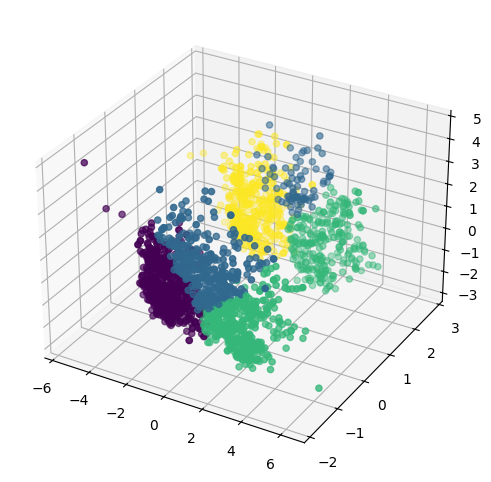

In [43]:
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2],c=labels_kmeans)

In [44]:
#AgglomerativeClustering
from sklearn.cluster import AgglomerativeClustering
agg_clf=AgglomerativeClustering(n_clusters=4,linkage="ward")
labels_agg=agg_clf.fit_predict(x_pca)

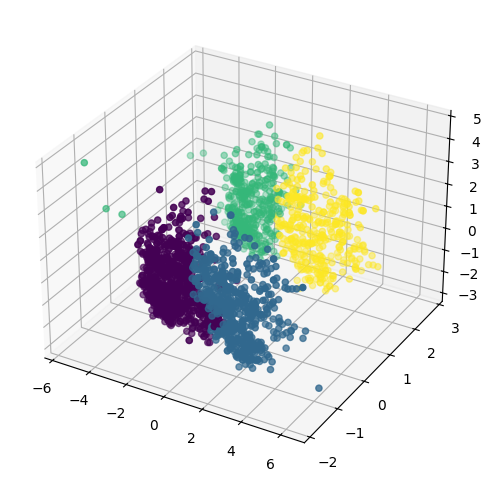

In [45]:
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2],c=labels_agg)

***Characterization of Clusters***

In [47]:
x["cluster"]=labels_agg

In [48]:
x.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Cutsomer_Tenure_Days,Total_Spendings,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='cluster', ylabel='count'>

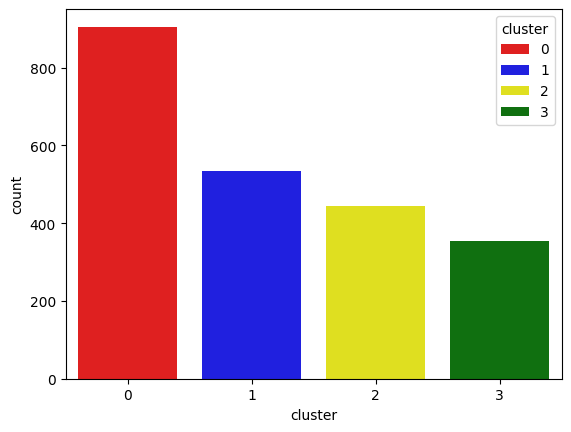

In [50]:
pal=["red","blue","yellow","green"]
sns.countplot(x=x["cluster"],palette=pal,hue=x["cluster"])

***Income And Spending Patterns***

<Axes: xlabel='Total_Spendings', ylabel='Income'>

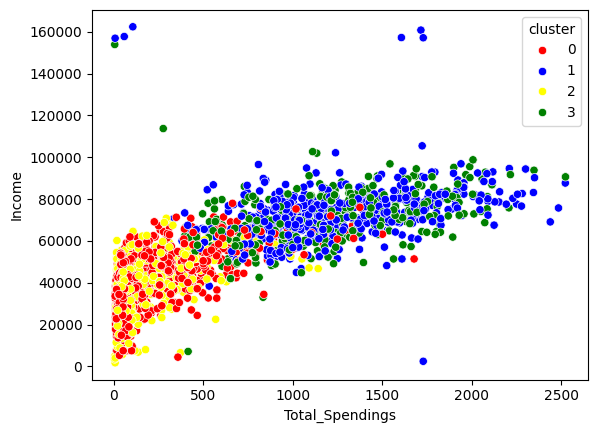

In [51]:
sns.scatterplot(x=x["Total_Spendings"],y=x["Income"],hue=x["cluster"],palette=pal)

In [52]:
#Cluster Summary
cluster_summary= x.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  Cutsomer_Tenure_Days  Total_Spendings  \
cluster        